# Data Analysis

### Libraries

In [79]:
import os
import pandas as pd
import numpy as np

# visualization and plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# text libraries imports
from textblob import TextBlob

# other imports
import importlib as imptlib
import IUMmodule as IUMmodule
imptlib.reload(IUMmodule)

# counfiguration
pio.templates.default = "plotly_dark"
plt.style.use('ggplot')

### Reading Data

In [80]:
df_languages = pd.read_csv('../data/languages.csv')
df_movies = pd.read_csv('../data/movies.csv')
df_posters = pd.read_csv('../data/posters.csv')
df_releases = pd.read_csv('../data/releases.csv')
df_studios = pd.read_csv("../data/studios.csv")
df_themes = pd.read_csv("../data/themes.csv")
df_reviews = pd.read_csv('../data/rotten_tomatoes_reviews.csv')
df_oscars = pd.read_csv('../data/the_oscar_awards.csv')
df_actors = pd.read_csv('../data/actors.csv')
df_countries = pd.read_csv('../data/countries.csv')
df_crew = pd.read_csv('../data/crew.csv')
df_genres = pd.read_csv('../data/genres.csv')

### Data shapes

In [81]:
print(df_languages.shape)
print(df_movies.shape)
print(df_posters.shape)
print(df_releases.shape)
print(df_studios.shape)
print(df_themes.shape)
print(df_oscars.shape)
print(df_reviews.shape)
print(df_actors.shape)
print(df_countries.shape)
print(df_crew.shape)
print(df_genres.shape)

(1038762, 3)
(941597, 7)
(941597, 2)
(1332782, 5)
(679283, 2)
(125641, 2)
(10889, 7)
(1129887, 9)
(5798450, 3)
(693476, 2)
(4720183, 3)
(1046849, 2)


### Data types

In [82]:
print("Languages types:\n", df_languages.dtypes, "\n")
print("Movies types:\n",df_movies.dtypes,"\n")
print("Posters types:\n",df_posters.dtypes,"\n")
print("Releases types:\n",df_releases.dtypes,"\n")
print("Studios types:\n", df_studios.dtypes, "\n")
print("Themes types:\n",df_themes.dtypes,"\n")
print("Reviews_types:\n",df_reviews.dtypes,"\n")
print("Oscars types:\n",df_oscars.dtypes,"\n")
print("Actors types:\n",df_actors.dtypes,"\n")
print("Countries types:\n",df_countries.dtypes,"\n")
print("Crew types:\n",df_crew.dtypes,"\n")
print("Genres types:\n",df_genres.dtypes,"\n")

Languages types:
 id           int64
type        object
language    object
dtype: object 

Movies types:
 id               int64
name            object
date           float64
tagline         object
description     object
minute         float64
rating         float64
dtype: object 

Posters types:
 id       int64
link    object
dtype: object 

Releases types:
 id          int64
country    object
date       object
type       object
rating     object
dtype: object 

Studios types:
 id         int64
studio    object
dtype: object 

Themes types:
 id        int64
theme    object
dtype: object 

Reviews_types:
 rotten_tomatoes_link    object
movie_title             object
critic_name             object
top_critic                bool
publisher_name          object
review_type             object
review_score            object
review_date             object
review_content          object
dtype: object 

Oscars types:
 year_film         int64
year_ceremony     int64
ceremony          int64
categ

# Converting columns into correct data types

### Converting "actors.csv" columns into types

In [83]:
df_actors["name"] = df_actors["name"].astype('string')
df_actors["role"] = df_actors["role"].astype('string')

### Converting "countries.csv" columns into types

In [84]:
df_countries["country"] = df_countries["country"].astype('string')

### Converting "crew.csv" columns into types

In [85]:
df_crew["role"] = df_crew["role"].astype('string')
df_crew["name"] = df_crew["name"].astype('string')

### Converting "genres.csv" columns into type

In [86]:
df_genres["genre"] = df_genres["genre"].astype('string')

### Converting "languages.csv" columns into type

In [87]:
df_languages['type'] = df_languages['type'].astype('string')
df_languages['language'] = df_languages['language'].astype('string')

### Converting "movies.csv" columns into type

In [88]:
df_movies['name'] = df_movies['name'].astype('string')
df_movies['date'] = pd.to_datetime(df_movies['date'],
errors='coerce', format='%Y').fillna(pd.to_datetime(df_movies['date'],errors='coerce'))
df_movies['tagline'] = df_movies['tagline'].astype('string')
df_movies['description'] = df_movies['description'].astype('string')

### Converting "posters.csv" columns into type

In [89]:
df_posters['link'] = df_posters['link'].astype('string')

### Converting "releases.csv" columns into type

In [90]:
df_releases['date'] = pd.to_datetime(df_releases['date'],
errors='coerce', format='%Y').fillna(pd.to_datetime(df_releases['date'],errors='coerce'))
df_releases['type'] = df_releases['type'].astype('string')
df_releases['rating'] = df_releases['rating'].astype('string')
df_releases['country'] = df_releases['country'].astype('string')

### Converting "studios.csv" column types

In [91]:
df_studios['studio'] = df_studios['studio'].astype('string')

### Converting "themes.csv" column types

In [92]:
df_themes['theme'] = df_themes['theme'].astype('string')

### Converting "rotten_tomatoes_reviews.csv" column types

In [93]:
df_reviews['rotten_tomatoes_link'] = df_reviews['rotten_tomatoes_link'].astype('string')
df_reviews['movie_title'] = df_reviews['movie_title'].astype('string')
df_reviews['critic_name'] = df_reviews['critic_name'].astype('string')
df_reviews['publisher_name'] = df_reviews['publisher_name'].astype('string')
df_reviews['review_type'] = df_reviews['review_type'].astype('string')
df_reviews['review_score'] = df_reviews['review_score'].astype('string')
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'], errors = 'coerce', format = '%Y').fillna(pd.to_datetime(df_reviews['review_date'], errors = 'coerce'))
df_reviews['review_content'] = df_reviews['review_content'].astype('string')

### Converting "the_oscar_awards.csv" column types

In [94]:
df_oscars['category'] = df_oscars['category'].astype('string')
df_oscars['name'] = df_oscars['name'].astype('string')
df_oscars['film'] = df_oscars['film'].astype('string')

# Cleaning data

### Checking NaN values and duplicates in "languages.csv" dataset
We have no duplicates or NaN values in this dataset

In [95]:
#Checking naN values
print("\nNaN values in column ID\n",df_languages['id'].isna().sum())
print("\nNaN values in column TYPE\n",df_languages['type'].isna().sum())
print("\nNaN values in column LANGUAGE\n",df_languages['language'].isna().sum())

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_languages.duplicated().sum()}\n")

#Cleaning spaces at the beginning and at the end of the strings
df_languages[["type", "language"]] = df_languages[["type", "language"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")


All columns with 'string' data type are now trimmed


### Checking naN values and duplicates in "movies.csv" dataset
We have no duplicates in this dataset and ID values are never NaN


In [96]:
#Checking naN values
print("NaN values in column ID\n",df_movies["id"].isna().sum())
print("\nNaN values in column NAME\n",df_movies["name"].isna().sum())
print("\nNaN values in column DATE\n",df_movies["date"].isna().sum())
print("\nNaN values in column TAGLINE\n",df_movies["tagline"].isna().sum())
print("\nNaN values in column DESCRIPTION\n",df_movies["description"].isna().sum())
print("\nNaN values in column MINUTE\n",df_movies["minute"].isna().sum())
print("\nNaN values in column RATING\n",df_movies["rating"].isna().sum())

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_movies.duplicated().sum()}")


Number of duplicated rows: 0


### Cleaning "movies.csv"

In [97]:
#Removing rows with NaN values in column 'name'
df_movies = df_movies.loc[~df_movies['name'].isna()]
print("NaN values left in column ['name']:\n", df_movies['name'].isna().sum())

#Cleaning spaces at the beginning and at the end of the strings
df_movies[["name","tagline","description"]] = df_movies[["name","tagline","description"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")


All columns with 'string' data type are now trimmed


### Checking for outliers in 'rating' from "movies.csv"
No outliers found

In [98]:
#Checking if 'rating' values are in [0,5] range
print("Values <0 in RATING\n",df_movies.query('rating<0'))
print("\nValues >5 in RATING\n",df_movies.query('rating>5'))

Values <0 in RATING
 Empty DataFrame
Columns: [id, name, date, tagline, description, minute, rating]
Index: []

Values >5 in RATING
 Empty DataFrame
Columns: [id, name, date, tagline, description, minute, rating]
Index: []


### Checking naN values and duplicates in "posters.csv" dataset
ID values are never NaN and we found no duplicated lines

In [99]:
#Checking NaN values
print("NaN values in column ID\n",df_posters['id'].isna().sum())
print("\nNaN values in column LINK\n",df_posters['link'].isna().sum())

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_posters.duplicated().sum()}")

### Cleaning "posters.csv"

In [100]:
#Removing rows with NaN values in column 'link'
df_posters = df_posters.loc[~df_posters['link'].isna()]
print("NaN values left in column ['link']:\n", df_posters['link'].isna().sum())

NaN values left in column ['link']:
 0


### Checking naN values and duplicates in "releases.csv" dataset
There are no duplicated lines or NaN values in ID, country, date, type

In [101]:
#Checking naN values
print("\nNaN values in column COUNTRY\n",df_releases['country'].isna().sum())
print("\nNaN values in column DATE\n",df_releases['date'].isna().sum())
print("\nNaN values in column TYPE\n",df_releases['type'].isna().sum())
print("\nNaN values in column RATING\n",df_releases['rating'].isna().sum())

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_releases.duplicated().sum()}")


Number of duplicated rows: 0


### Cleaning "releases.csv"

In [102]:
#Changing 'rating' in 'age_rating'
df_releases.rename(columns={'rating' : 'age_rating'}, inplace= True)

#Cleaning spaces at the beginning and at the end of the strings
df_releases[["country","type"]] = df_releases[["country","type"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")


All columns with 'string' data type are now trimmed


### Checking if the values in column 'country' from "releases.csv" are consistent


The United States and The United Kingdom are only refered as USA and UK


Russia and Russian Federation has the same number of rows so they are consistent

In [103]:
#The United States and The United Kingdom
print("\n",df_releases[df_releases['country'].str.contains('united states', case=False)][['id', 'country']])
print("\n",df_releases[df_releases['country'].str.contains('america', case=False)][['id', 'country']])
print("\n",df_releases[df_releases['country'].str.contains('england', case=False)][['id', 'country']])
print("\n",df_releases[df_releases['country'].str.contains('britain', case=False)][['id', 'country']])
print("\n",df_releases[df_releases['country'].str.contains('great britain', case=False)][['id', 'country']])

#Russia and Russian Federation
print("\n",df_releases[df_releases['country'].str.contains('russia', case=False)][['id', 'country']])
print("\n",df_releases[df_releases['country'].str.contains('russian federation', case=False)][['id', 'country']])


               id             country
165      1000002  Russian Federation
166      1000002  Russian Federation
167      1000002  Russian Federation
258      1000003  Russian Federation
331      1000004  Russian Federation
...          ...                 ...
1332256  1940458  Russian Federation
1332259  1940461  Russian Federation
1332344  1940544  Russian Federation
1332589  1940777  Russian Federation
1332673  1940863  Russian Federation

[24838 rows x 2 columns]


### Standardizing the 'rating' column's values in "releases.csv"
We normalized column 'age_rating' in relases.csv so now we can use these values for our data analysis

In [104]:
df_releases['age_rating'] = df_releases['age_rating'].apply(IUMmodule.standardazing_age_ratings)

print("\n",df_releases['age_rating'].value_counts())


 age_rating
Unrated    1114889
12+          66738
18+          43861
16+          32338
15+          25896
G            20999
13+          15419
14+           6330
11+           3000
10+           2744
17+            568
Name: count, dtype: int64


### Finding duplicates and NaN values in "genres.csv"
We found no duplicated lines or NaN values

In [105]:
#Checking duplicated lines if exists
print(f"Number of duplicated rows: {df_genres.duplicated().sum()}\n")

#Checking naN values
print("\nNan values in column ID\n",df_genres['id'].isna().sum())
print("\nNan values in column GENRE\n",df_genres['genre'].isna().sum())

#Cleaning spaces at the beginning and at the end of the strings
df_genres[["genre"]] = df_genres[["genre"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")

Number of duplicated rows: 0


Nan values in column ID
 0

Nan values in column GENRE
 0

All columns with 'string' data type are now trimmed


In [106]:
print(df_genres["genre"].value_counts())

genre
Drama              232201
Documentary        163890
Comedy             140636
Animation           58708
Horror              53870
Romance             51549
Thriller            46726
Music               44105
Action              41695
Crime               35507
Family              27511
TV Movie            25874
Adventure           23093
Fantasy             22280
Mystery             21394
Science Fiction     21209
History             17008
War                 10758
Western              8835
Name: count, dtype: Int64


### Finding duplicates and NaN values in "countries.csv"
We found no duplicated lines or NaN values

In [107]:
#Checking duplicated lines if exists
print(f"Number of duplicated rows: {df_countries.duplicated().sum()}\n")

#Checking naN values
print("\nNaN values in column ID\n",df_countries['id'].isna().sum())
print("\nNaN values in column COUNTRY\n",df_countries['country'].isna().sum())

#Cleaning spaces at the beginning and at the end of the strings
df_countries[["country"]] = df_countries[["country"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")

Number of duplicated rows: 0


NaN values in column ID
 0

NaN values in column COUNTRY
 0

All columns with 'string' data type are now trimmed


### Finding duplicates and NaN values in "crew.csv"
We found some duplicated rows but ID and ROLE are never NaN

In [108]:
#Checking duplicated lines if exists
print(f"Number of duplicated rows: {df_crew.duplicated().sum()}\n")
print("\nDropping duplicated values...\n")
df_crew = df_crew.drop_duplicates()
print("\nDuplicated values after cleaning\n", df_crew.loc[df_crew.duplicated()])

#Checking naN values
print("\nNaN values in column ID\n",df_crew['id'].isna().sum())
print("\nNaN values in column NAME\n",df_crew['name'].isna().sum())
print("\nNaN values in column ROLE\n",df_crew['role'].isna().sum())

#!!!!!!!!!!!!!!!!!!!!!!!!!!! Serve?
#df_crew = df_crew.dropna(subset=["id"])

#Removing on row with "name" = NaN
df_crew = df_crew.dropna(subset=["name"])

#Cleaning spaces at the beginning and at the end of the strings
df_crew[["role", "name"]] = df_crew[["role", "name"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")

#!!!!!!!!!!!!!!!!!!!!!!!!!!! Questo non va bene
#print("\nDropping NaN values...\n",df_crew.dropna(subset=["name"]))


All columns with 'string' data type are now trimmed


In [109]:
print(df_countries["country"].value_counts().head(10))

country
USA        174489
France      45725
UK          42914
Japan       41362
Germany     41325
Canada      23054
India       22393
Italy       19377
Brazil      17212
Spain       16860
Name: count, dtype: Int64


### Finding duplicates and NaN values in "actors.csv"
We found some duplicated and we removed the rows where both "name" and "role" were NaN

In [110]:
#Checking naN values
print("\nNaN values in column ID\n",df_actors['id'].isna().sum())
print("\nNaN values in column NAME\n",df_actors['name'].isna().sum())
print("\nNaN values in column ROLE\n",df_actors['role'].isna().sum())
#!!!!!!!!!!!!!!!!!!!!!!!!!!! Serve?
#df_actors.dropna(subset=['name'], inplace=True)

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_actors.duplicated().sum()}")
df_actors = df_actors.drop_duplicates()

#Removing lines where "name" and "role" are both NaN
df_actors = df_actors.dropna(subset=['name', 'role'], how='all')

#!!!!!!!!!!!!!!!!!!!!!!!!!!! Serve?
#df_actors = df_actors.dropna(subset=["name"])


Number of duplicated rows: 946


### Cleaning "actors.csv"

In [111]:
#Cleaning spaces at the beginning and at the end of the strings
df_actors[["role", "name"]] = df_actors[["role", "name"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")


All columns with 'string' data type are now trimmed


### Create a new row for each role for the same "id" and "name" in "actors.csv"

In [112]:
#df_actors_expanded = df_actors.assign(
#    role=df_actors["role"].str.split(" / ")
#).explode("role").reset_index(drop=True)
#print(df_actors_expanded[df_actors_expanded["id"] == 1009952])

### Checking for invalid values and duplicates in "studios.csv"
We found some duplicates and we removed the rows where "studio" were NaN

In [113]:
#Checking naN values
print("NaN values in column id:\n",df_studios['id'].isna().sum(),"\n")
print("NaN values in column studios:\n",df_studios['studio'].isna().sum(),"\n")
df_studios = df_studios.loc[~df_studios['studio'].isna()]

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_studios.duplicated().sum()}")
df_studios = df_studios.loc[~df_studios.duplicated()]

#Cleaning spaces at the beginning and at the end of the strings
df_studios[["studio"]] = df_studios[["studio"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")


All columns with 'string' data type are now trimmed


### Checking for invalid values and duplicates in themes.csv
We found no duplicated lines or NaN values

In [114]:
#Checking naN values
print("NaN values in column ID:\n",df_themes['id'].isna().sum(),"\n")
print("NaN values in column THEME:\n", df_themes['theme'].isna().sum(),"\n")

#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_themes.duplicated().sum()}")

#Cleaning spaces at the beginning and at the end of the strings
df_themes[["theme"]] = df_themes[["theme"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")

NaN values in column ID:
 0 

NaN values in column THEME:
 0 


Number of duplicated rows: 0

All columns with 'string' data type are now trimmed


### Checking for invalid values and duplicates in rotten_tomatoes_reviews.csv
We found some duplicated line, we also found NaN values in the following columns: "critic_name", "review_score" and "review_content". We decided to remove only the rows where both "review_score" and "review_content" were NaN and all three columns were NaN

In [115]:
#Checking naN values
print("NaN values in column LINK:\n",df_reviews['rotten_tomatoes_link'].isna().sum(),"\n")
print("NaN values in column MOVIE_TITLE:\n",df_reviews['movie_title'].isna().sum(),"\n")
print("NaN values in column CRITIC_NAME:\n",df_reviews['critic_name'].isna().sum(),"\n")
print("NaN values in column TOP_CRITIC:\n",df_reviews['top_critic'].isna().sum(),"\n")
print("NaN values in column PUBLISHER_NAME:\n",df_reviews['publisher_name'].isna().sum(),"\n")
print("NaN values in column REVIEW_TIPE:\n",df_reviews['review_type'].isna().sum(),"\n")
print("NaN values in column REVIEW_SCORE:\n",df_reviews['review_score'].isna().sum(),"\n")
print("NaN values in column REVIEW_DATE:\n",df_reviews['review_date'].isna().sum(),"\n")
print("NaN values in column REVIEW_CONTENT:\n",df_reviews['review_content'].isna().sum(),"\n")
print("NaN values in REVIEW_SCORE and REVIEW_CONTENT:\n", (df_reviews['review_score'].isna() & df_reviews['review_content'].isna()).sum())
print("NaN values in CRITIC_NAME, REVIEW_SCORE and REVIEW_CONTENT:\n", (df_reviews['critic_name'].isna() & df_reviews['review_score'].isna() & df_reviews['review_content'].isna()).sum())

df_reviews = df_reviews.loc[~(df_reviews['review_score'].isna() & df_reviews['review_content'].isna())]

df_reviews = df_reviews.loc[~(df_reviews['critic_name'].isna() & df_reviews['review_score'].isna() & df_reviews['review_content'].isna())]


#Checking duplicated lines if exists
print(f"\nNumber of duplicated rows: {df_reviews.duplicated().sum()}")

df_reviews = df_reviews.loc[~df_reviews.duplicated()]


Number of duplicated rows: 119427


### Checking outliers in dataset "rotten_tomatoes_reviews.csv"

In [116]:
date_outliers = df_reviews[
    (df_reviews['review_date'].dt.year < 1998) |   # rotten tomatoes was created in 1998
    (df_reviews['review_date'].dt.year > 2025)
]

print(f"There are:", len(date_outliers), "reviews that are out of range")
print(f"The percentage of reviews with invalid dates is {len(date_outliers)/len(df_reviews)*100:.2f}% of the total reviews.")

There are: 1089 reviews that are out of range
The percentage of reviews with invalid dates is 0.11% of the total reviews.


Since the percentage of temporal outliers is very low (0.11%), and given that we cannot determine with certainty whether these reviews are errors or valid entries with unusual dates, we have decided to remove them from the dataset to ensure consistency in the temporal analysis.

In [117]:
df_reviews = df_reviews.drop(date_outliers.index)

### Cleaning column "views_score" in dataset "rotten_tomatoes_reviews.csv"

In [118]:
df_reviews['review_score'].value_counts()

review_score
3/5             80871
4/5             74893
3/4             64475
2/5             53827
2/4             42420
                ...  
9.649821/10         1
3/45                1
8.692121/10         1
70                  1
4.9834326/10        1
Name: count, Length: 814, dtype: Int64

The 'review_score' column contains highly inconsistent formats (e.g., '77', '9.021/10', '2/5', 'C+', '25/4').
Checking for unusual numerical ranges and non-numerical grades (A+, F-) before applying custom cleaning.

In [119]:
count = df_reviews['review_score'].str.extract(r'(\d+)').astype(float)
print("Number of reviews that are greater than 99 and smaller than 1000:",((count > 99)&(count < 1000)).sum())
print("Number of reviews that are greater than 999:",(count > 999).sum())
print("Number of scores with value A+:",df_reviews['review_score'].str.contains(r'A+', na=False).sum())
print("Number of scores with value F-:",df_reviews['review_score'].str.contains(r'F-', na=False).sum())

Number of reviews that are greater than 99 and smaller than 1000: 0    20
dtype: int64
Number of reviews that are greater than 999: 0    0
dtype: int64
Number of scores with value A+: 18623
Number of scores with value F-: 0


### Applies two custom modules to standardize the 'review_score' column

In [120]:
# convert_grade_to_5_scale: Handles letter grades (A, B, C...) and non-normalized fraction formats.
df_reviews['review_score'] = df_reviews['review_score'].apply(IUMmodule.convert_grade_to_5_scale)
# normalize_review_score: Ensures all remaining numerical/fractional scores are consistently scaled to a X/5 format.
df_reviews['review_score'] = df_reviews['review_score'].apply(IUMmodule.normalize_review_score)

print("Number of scores /5:",df_reviews['review_score'].str.contains(r'/5', na=False).sum())
print("Number of Not NaN scores:",df_reviews['review_score'].notna().sum())

Number of scores /5: 735737
Number of Not NaN scores: 735737


### Converting values in column "review_score" into float type

In [121]:
df_reviews['review_score'] = df_reviews['review_score'].apply(IUMmodule.convert_to_float)

##### The statistical summary and box plot confirm that the custom cleaning and normalization steps (convert_grade_to_5_scale and normalize_review_score) were successful in aligning the numerical scores with the categorical review type:
The mean score for "Fresh" reviews (approx. 3.85) is significantly higher than the mean score for "Rotten" reviews (approx. 2.16). This indicates that the review scores, after cleaning, correctly reflect the critical consensus (Fresh/Rotten) assigned by the platform.\
The median scores (50 percentile) are 4.0 for Fresh and 2.0 for Rotten. This reinforces the separation.\
The interquartile range (25% to 75%) shows that 75\% of Fresh reviews have a score of 3.5 or higher, while 75\% of Rotten reviews have a score of 2.5 or lower.

The presence of scores of 0.0 and 5.0 in both categories indicates that while the normalization worked, there may still be a few edge cases (e.g., a critic giving a 0.0 but the platform marking it as "Fresh" due to another factor, or vice-versa). These minimal outliers are expected after massive data cleaning and do not compromise the overall quality for analysis.

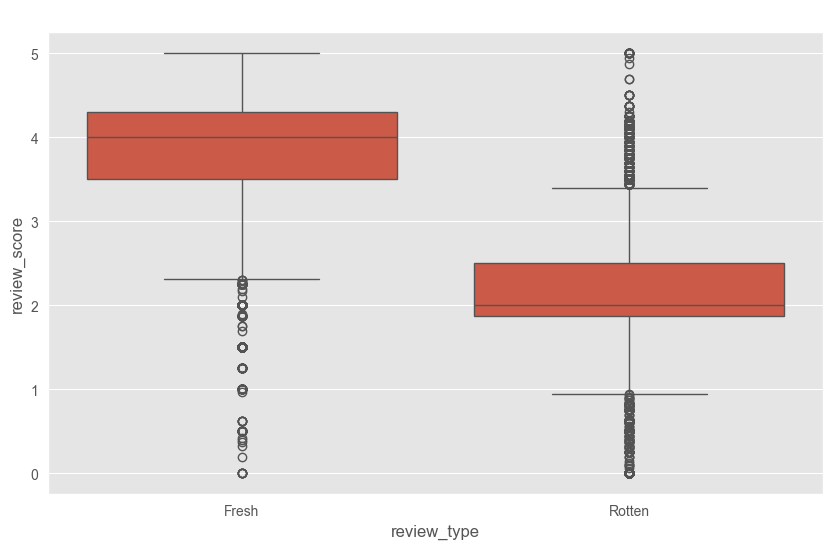

In [122]:
# statistics
score_stats = df_reviews.groupby('review_type')['review_score'].describe()
print(score_stats)

# Boxplot to visualize the distribution of the scores
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_type', y='review_score', data=df_reviews)
plt.title('Distribution of the scores by review type')
plt.show()

### Counting the outliers in the scores:
This cell counts how many rows there are in the dataset where the normalized review_score (on a 0-5 scale) conflicts with the assigned review_type label.
The number of Rotten outliers is significant. However, given that the normalized score is the most valuable quantitative information for our analysis, and the Fresh/Rotten classification is often a secondary, sometimes auto-assigned, label, the decision is to keep these rows.

In [123]:
outliers_fresh = df_reviews[(df_reviews['review_type'] == 'Fresh') & (df_reviews['review_score'] <= 2.5)]
outliers_rotten = df_reviews[(df_reviews['review_type'] == 'Rotten') & (df_reviews['review_score'] > 2.5)]

print(f"Outliers Fresh: {len(outliers_fresh)}")
print(f"Outliers Rotten: {len(outliers_rotten)}")

Outliers Fresh: 5516
Outliers Rotten: 61409


### Checking for invalid values and duplicates in the_oscar_awards.csv
We found some duplicated line, we also found NaN values in the following columns: "name", and "film". We decided to remove only the rows where both "name" and "films" were NaN

In [124]:
print("NaN values in column YEAR_FILM:\n",df_oscars['year_film'].isna().sum(),"\n")
print("NaN values in column YEAR_CEREMONY:\n",df_oscars['year_ceremony'].isna().sum(),"\n")
print("NaN values in column CEREMONY:\n",df_oscars['ceremony'].isna().sum(),"\n")
print("NaN values in column CATEGORY:\n",df_oscars['category'].isna().sum(),"\n")
print("NaN values in column NAME:\n",df_oscars['name'].isna().sum(),"\n")
print("NaN values in column FILM:\n",df_oscars['film'].isna().sum(),"\n")
print("NaN values in column WINNER:\n",df_oscars['winner'].isna().sum(),"\n")
print("NaN values in FILM and NAME:\n", (df_oscars['film'].isna() & df_oscars['name'].isna()).sum())

# Drop rows where both 'FILM' and 'NAME' (critical identification fields) are missing.
df_oscars = df_oscars.loc[~(df_oscars['film'].isna() & df_oscars['name'].isna())]

# Drop duplicates
print(f"\nNumber of duplicated rows: {df_oscars.duplicated().sum()}")
df_oscars = df_oscars.loc[~df_oscars.duplicated()]

#Cleaning spaces at the beginning and at the end of the strings
df_oscars[["category", "name", "film"]] = df_oscars[["category", "name", "film"]].apply(
    lambda column_element: column_element.where(column_element.notna(), column_element).str.strip()
)
print("\nAll columns with 'string' data type are now trimmed")

NaN values in column YEAR_FILM:
 0 

NaN values in column YEAR_CEREMONY:
 0 

NaN values in column CEREMONY:
 0 

NaN values in column CATEGORY:
 0 

NaN values in column NAME:
 5 

NaN values in column FILM:
 319 

NaN values in column WINNER:
 0 

NaN values in FILM and NAME:
 5

Number of duplicated rows: 6

All columns with 'string' data type are now trimmed


### Checking if there are outliers in "the_oscars_awards.csv"

In [125]:
# checking if all the film’s release year is the year before the ceremony year
print("Number of inconsistent values between year_film and year_ceremony:",len(df_oscars[df_oscars['year_ceremony'] != (df_oscars['year_film'] + 1)]))

# checking if there are inconsistency in the year_ceremony column:
print("Number of oscars given before 1929:",(df_oscars['year_ceremony'] < 1929).sum())
print("The outliers are:",df_oscars[df_oscars['year_ceremony'] < 1929]['year_ceremony'].unique())
print("Highest value in column year_ceremony:", df_oscars['year_ceremony'].max())

# checking if there are missing years
all_years = set(range(1929, df_oscars['year_ceremony'].max() + 1))
present_years = set(df_oscars['year_ceremony'].unique())
missing_years = all_years - present_years
if missing_years:
     print(f"There are {len(missing_years)} missing years and they are: {sorted(missing_years)}")

Number of inconsistent values between year_film and year_ceremony: 0
Number of oscars given before 1929: 35
The outliers are: [1928]
Highest value in column year_ceremony: 2024
There are 1 missing years and they are: [1934]


Output of this cell revealed a pattern where ceremony years 1929-1933 were shifted backward by one year (e.g., 1929 data marked as 1928).

In [126]:
df_oscars[df_oscars['year_ceremony'].isin([1928, 1929, 1930, 1931, 1932, 1933])]

,year_film,year_ceremony,ceremony,category,name,film,winner
0,1927,1928,1,ACTOR,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,Emil Jannings,The Last Command,True
2,1927,1928,1,ACTRESS,Louise Dresser,A Ship Comes In,False
3,1927,1928,1,ACTRESS,Janet Gaynor,7th Heaven,True
4,1927,1928,1,ACTRESS,Gloria Swanson,Sadie Thompson,False
...,...,...,...,...,...,...,...
261,1932,1933,6,WRITING (Adaptation),"Victor Heerman, Sarah Y. Mason",Little Women,True
262,1932,1933,6,WRITING (Adaptation),"Paul Green, Sonya Levien",State Fair,False
263,1932,1933,6,WRITING (Original Story),Robert Lord,One Way Passage,True
264,1932,1933,6,WRITING (Original Story),Frances Marion,The Prizefighter and the Lady,False


Manual inspection of the data for the earliest Oscar years (1928-1933) revealed a consistent data shift: the data corresponds to a year later than recorded in the source. For example, the entries marked as year_ceremony = 1928 actually belong to the 1929 ceremony, and this pattern continues until 1933 (which contained 1934 data).

This pattern is being corrected by incrementing the year_ceremony and year_film columns by one year for all ceremonies before 1934, ensuring consistency with the official Oscar ceremony numbering.

In [127]:
mask = df_oscars['year_ceremony'] < 1934
expected_ceremony = df_oscars['year_ceremony'] - 1927

# Check if the ceremony number matches the expected number (Ceremony Year - 1928) before correcting
incorrect_ceremonies = df_oscars.loc[mask, 'ceremony'] != expected_ceremony[mask]
if incorrect_ceremonies.sum() == 0:
    df_oscars.loc[mask, 'year_ceremony'] += 1
    df_oscars.loc[mask, 'year_film'] += 1
else:
    print(f"There are {incorrect_ceremonies.sum()} rows where the column ceremony does not match with the column year_ceremony.")

print("Number of oscars given in 1934:",(df_oscars['year_ceremony'] == 1934).sum())

# checking if the values in the column ceremony match with the values inside year_ceremony in the whole dataset
expected_ceremony = df_oscars['year_ceremony'] - 1928
incorrect_ceremonies = df_oscars['ceremony'] != expected_ceremony
print(f"There are {incorrect_ceremonies.sum()} rows where the column ceremony does not match with the column year_ceremony in the entire dataset.")

Number of oscars given in 1934: 62
There are 0 rows where the column ceremony does not match with the column year_ceremony in the entire dataset.


The df_oscars dataset lacked a common movie ID for joining with other movie dataframes (e.g., df_movies). To resolve this, we used a function (IUMmodule.find_matching_movie) to assign an ID based on a fuzzy match of Film Title and Year from the df_movies dataset.

In [128]:
title_to_id, norm_title_to_id, year_to_titles = IUMmodule.build_lookup_structures(df_movies, df_oscars)

# apply the function to find the matching movie ID
df_oscars['id'] = df_oscars.apply(
    lambda row: IUMmodule.find_matching_movie(row['film'], row['year_film'], title_to_id, norm_title_to_id, year_to_titles),
    axis=1
)

Displaying the entries that had a film title but could not be matched to a movie ID.

In [129]:
print(df_oscars['film'].isna())

0        False
1        False
2        False
3        False
4        False
         ...  
10883    False
10884    False
10886     True
10887     True
10888     True
Name: film, Length: 10878, dtype: bool


In [130]:
df_oscars.loc[df_oscars['id'].isna() & (~df_oscars['film'].isna())]

,year_film,year_ceremony,ceremony,category,name,film,winner,id
24,1928,1929,1,UNIQUE AND ARTISTIC PICTURE,Paramount Famous Lasky,Chang,False,NaN
65,1929,1930,2,OUTSTANDING PICTURE,Metro-Goldwyn-Mayer,Hollywood Revue,False,NaN
551,1937,1938,10,ART DIRECTION,Alexander Toluboff,Walter Wanger's Vogues of 1938,False,NaN
595,1937,1938,10,MUSIC (Song),Music by Sammy Fain; Lyrics by Lew Brown,Walter Wanger's Vogues of 1938,False,NaN
828,1939,1940,12,CINEMATOGRAPHY (Color),"Georges Perinal, Osmond Borradaile",Four Feathers,False,NaN
...,...,...,...,...,...,...,...,...
9688,2014,2015,87,DOCUMENTARY (Short Subject),Gabriel Serra Arguello,The Reaper (La Parka),False,NaN
9981,2016,2017,89,SHORT FILM (Live Action),Sélim Azzazi,Ennemis Intérieurs,False,NaN
10356,2019,2020,92,SHORT FILM (Animated),Daria Kashcheeva,Dcera (Daughter),False,NaN
10814,2023,2024,96,DOCUMENTARY SHORT FILM,Sean Wang and Sam Davis,Nai Nai & Wài Pó,False,NaN


since there were only 103 entries that had a film name but could not be matched to an ID in df_movies, we decided to remove them, as the cannot be used for cross-dataset analysis

In [131]:
df_oscars = df_oscars.loc[~df_oscars['id'].isna()]
df_oscars['id'] = df_oscars['id'].astype('int')
print(f"df_oscars shape after removal: {df_oscars.shape}")

df_oscars shape after removal: (10461, 8)


## Review Analisis

From the analysis below, we can observe that the records without an ID have a slightly higher proportion of top critics (1.7%).\
Plus, the p-value of 0 indicates that the probability of observing such a difference in top critic proportions between the two groups is statistically significant.\
Finally, the negative sign of the z-score indicates that the proportion of top critics in the first group (those with an ID) is lower than in the second group. The magnitude (8.73) shows that the difference is far from zero in terms of standard deviations.\
For this reason, for analyses that require integration with other datasets, we will limit ourselves to records with an ID, while descriptive statistics on top critics will include all available data.

In [132]:
df_reviews = IUMmodule.generate_blocking_keys(df_reviews, 'movie_title', 'title_candidates', 'blocking_key')
df_movies = IUMmodule.generate_blocking_keys(df_movies, 'name', 'name_candidates', 'blocking_key')

# match
match_dict = IUMmodule.perform_recordlinkage(df_reviews, df_movies)

# apply
df_reviews['id'] = df_reviews.index.map(match_dict)

#cleanup
IUMmodule.cleanup_temp_columns(df_reviews, ['title_candidates', 'blocking_key'])
IUMmodule.cleanup_temp_columns(df_movies, ['name_candidates', 'blocking_key'])

In [133]:
missing_ids = df_reviews['id'].isna().sum()
total_reviews = len(df_reviews)
print(f"Reviews without an ID: {missing_ids} on {total_reviews} ({missing_ids/total_reviews:.2%})")

Reviews without an ID: 53473 on 1008938 (5.30%)


In [134]:
grouped = df_reviews.groupby(df_reviews['id'].isna())

# Summary statistics for 'top_critic'
stats = grouped['top_critic'].agg(['mean', 'sum', 'count', 'std'])
stats.rename(index={True: 'Senza_ID', False: 'Con_ID'}, inplace=True)
print(stats)

# STORY TELLING

## Global Distribution of Oscar Nominations

Our analysis begins with a global overview of the Oscars nominations.\
 While the United States and the UK lead in total numbers, countries like France, Italy, and Japan show a strong and consistent presence.\
 Looking at the nominations, instead of just wins reveals a muc broeader international landscape. \
 This geographic overview provides the necessary context before we dive deeper into how different genres and styles evolved across these regions over time.

### Data

In [135]:
# filter Oscars entries with a valid movie ID and merge with countries
oscars_with_country = pd.merge(
    df_oscars,
    df_countries,
    on='id',
    how='inner'
)

# aggregate nominations per country
nominations_per_country = (
    oscars_with_country.groupby('country').size().reset_index(name='nominations')
)

# aggregate wins per country
wins_per_country = (
    oscars_with_country[oscars_with_country['winner']]
    .groupby('country').size().reset_index(name='wins')
)

films_produced = (
    df_countries.groupby('country').size().reset_index(name='films_produced')
)

map_data = (
    nominations_per_country
    .merge(wins_per_country, on='country', how='left')
    .merge(films_produced, on='country', how='left')
    .fillna(0)
)

map_data['nominations_log'] = np.log10(map_data['nominations'].replace(0, 0.1))

### Charts

In [136]:
# Choropleth Map
fig = go.Figure(
    data=go.Choropleth(locations = map_data['country'],
    z = map_data['nominations_log'],
    locationmode = 'country names',
    colorscale = 'YlGnBu',
    customdata = np.stack((
    map_data['nominations'],
    map_data['wins'],
    map_data['films_produced']
    ), axis=-1),
    hovertemplate = (
        "<b>%{location}</b><br>" +
        "Nominations: %{customdata[0]:.0f}<br>" +
        "Wins: %{customdata[1]:.0f}<br>" +
        "Total Films Produced: %{customdata[2]:.0f}" +
        "<extra></extra>"
    )
))

fig.update_layout(
    title_text = '<b>Global Distribution of Oscar Nominations</b>',
    title_x = 0.5,
    geo = dict(
        showframe = False,
        showcoastlines = True,
        projection_type = 'equirectangular'
    ),
    margin = {"r":0, "t":80, "l":0, "b":0},
    height = 600
)
fig.show()

In [137]:
# cleanup
del oscars_with_country, wins_per_country, films_produced

##  Temporal Line Plot

While the global map shows who leads in total numbers, this timeline reveals how the influence has shifted. \
Since 1929, the United States has dominated the Oscars, reaching the golden era in the 1940s. Interestigly, while U.S. film production has exploded (going from 1,500 films annually in the 1980s to over 18,000 today) its annual Oscar nominations have remained relatively stable.\
European cinema shows a different pattern, with peaks that seems to be tied to specific historical movements: Italy reached its height  during the neorealism era (1940s–60s), while the UK saw great success with literary adaptations (1960s–90s). Today, although countries like France, Germany, and Spain produce hundreds of films annually, they struggle to match past Oscar success.\
 In Asia, Japan and South Korea the trend is more irregular, while India and China, despite producing thousands of films, rarely appear at the Oscars.\
 However, some countries have achieved great results, tied to specific francises:
- New Zealand: dominated 2004 thanks to The Lord of the Rings
- Australia and Denmark gained major recognition with film like Mad Max and The Promised Land
- Ireland: has earned nominations and wins with films like My Left Foot (1989) and The Banshees of Inisherin (2022).

### Data

In [138]:
df_reviews['top_critic_str'] = df_reviews['top_critic'].astype(str)# Country assignment for films
film_with_one_country = df_countries.groupby('id').filter(lambda x: len(x) == 1)[['id', 'country']]
film_first_release = (
    df_releases.sort_values(['id', 'date'])
    .drop_duplicates('id', keep='first')[['id', 'country']]
)
film_country_map = pd.concat([film_with_one_country, film_first_release])

# country-year production counts
films_by_country_year = (
    df_movies.merge(film_country_map, on='id')
    .assign(year_film=lambda x: x['date'].dt.year)
    .groupby(['country', 'year_film'])
    .size()
    .reset_index(name='films_produced')
)

# Nominations and wins per year/country
nominations_by_year = (
    df_oscars.merge(film_country_map, on='id')
    .assign(year_film=lambda x: x['year_film'])
    .groupby(['country', 'year_film']).size().reset_index(name='nominations')
)

wins_by_year = (
    df_oscars[df_oscars['winner']]
    .merge(film_country_map, on='id')
    .assign(year_film=lambda x: x['year_film'])
    .groupby(['country', 'year_film']).size().reset_index(name='wins')
)

# Final stats per country and year
annual_country_stats = (
    nominations_by_year
    .merge(wins_by_year, on=['country', 'year_film'], how='left')
    .merge(films_by_country_year, on=['country', 'year_film'], how='left')
    .fillna(1)  # Avoid division by zero
)
annual_country_stats['nomination_density'] = (
    annual_country_stats['nominations'] / annual_country_stats['films_produced']
)

# Select countries with at least 10 nominations
selected_countries = (
    annual_country_stats.groupby('country')['nominations'].sum()
    .loc[lambda x: x >= 10]
    .index.tolist()
)

# Top 10 countries by total nominations
top_10_countries = (
    annual_country_stats.groupby('country')['nominations'].sum()
    .nlargest(10).index.tolist()
)

# remove the countries that are already in the top ten
selected_countries = [c for c in selected_countries if c not in top_10_countries]

### Charts

In [139]:
fig = go.Figure()

# Add tracks for the top ten countries
for i, country in enumerate(top_10_countries):
    data = annual_country_stats[annual_country_stats['country'] == country]
    fig.add_trace(go.Scatter(
        x=data['year_film'],
        y=data['nominations'],
        mode='lines',
        name=country,
        visible=True,
        line=dict(color=px.colors.qualitative.Plotly[i % 10], width=2),
        customdata=np.stack((
            data['wins'],
            data['films_produced'],
            data['nomination_density']
        ), axis=-1),
        hovertemplate=(
            "<b>%{fullData.name} %{x}</b> <br>"
            "<b>Nominations:</b> %{y}, <b>Wins:</b> %{customdata[0]}<br>"
            "<b>Films Produced:</b> %{customdata[1]}<br>"
            "<extra></extra>"
        )
    ))

# Add tracks for the selected countries
for country in selected_countries:
    data = annual_country_stats[annual_country_stats['country'] == country]
    fig.add_trace(go.Scatter(
        x=data['year_film'],
        y=data['nominations'],
        mode='lines+markers',
        name=country,
        visible=False,
        line=dict(color='#2ca02c', width=3),
        marker=dict(size=8),
        customdata=np.stack((
            data['wins'],
            data['films_produced'],
            data['nomination_density']
        ), axis=-1),
        hovertemplate=(
            "<b>%{fullData.name}</b> <br>"
            "<b>Year:</b> %{x}<br>"
            "<b>Nominations:</b> %{y}<br>"
            "<b>Wins:</b> %{customdata[0]}<br>"
            "<b>Films Produced:</b> %{customdata[1]}<br>"
            "<b>Nomination Density:</b> %{customdata[2]:.3f}<br>"
            "<extra></extra>"
        )
    ))

# Create a dropdown menu
dropdown_options = [
    {'label': 'Top 10 Countries',
     'method': 'update',
     'args': [{'visible': [True]*10 + [False]*len(selected_countries)},
              {'title': 'Top 10 Countries: Oscar Nominations Over Time',
               'yaxis': {'title': 'Nominations'}}]}
]

for i, country in enumerate(selected_countries):
    dropdown_options.append(
        {'label': f'{country} (Total: {annual_country_stats[annual_country_stats["country"]==country]["nominations"].sum()})',
         'method': 'update',
         'args': [{'visible': [False]*10 + [j == i for j in range(len(selected_countries))]},
                  {'title': f'Oscar Nominations for {country}',
                   'yaxis': {'type': 'linear', 'title': 'Number of Nominations'}}]}
    )


fig.update_layout(

    updatemenus=[{
        'buttons': dropdown_options,
        'direction': 'down',
        'showactive': True,
        'x': 0.85,
        'xanchor': 'left',
        'y': 1.15,
        'yanchor': 'top',
        'font': {'color': '#000'},
    }],
    title="Top 10 Countries: Oscar Nominations Over Time",
    xaxis_title="Year",
    yaxis_title="Nominations",
    height=600,
    hovermode='x unified',
    legend_title="Country"
)
fig.show()

In [140]:
# cleanup
del film_with_one_country, film_first_release, films_by_country_year, nominations_by_year, wins_by_year, selected_countries, top_10_countries

## PUNTO 2: Quantifying the Critic Profile


After exploring historical trends and Oscar nominations, we now shift our focus to the critical reception. By analyzing Rotten Tomatoes data, we can quantify the difference in judgment between 'Top Critics' and standard reviewers.


As we can see, the two violin plots are relatively symmetrical and bell-shaped, indicating that, despite their strictness, top critics are not "polarized".
We can also notice that the violin plot for non-top critics is slightly wider in the middle, suggesting a higher concentration of ratings in that range\
Our analysis confirms the Top Critic are generally stricter:
The strictness of the top critics is confirmed by the statistics:
   - top critics score films 0.09 points lower, on average (3.25 vs 3.16)
   - the top critic median of 3.12 is lower than the standard critic of 3.30
All this data confirms that the average Rop Critic is more likely to give a lower score.

Furthermore, the standard deviation (around 1.05) is nearly identical for both groups, which suggests that the difference in the score does not change the overall sentiment of the reviews.

This systematic shift in score does impact the category boundaries (Positive > 3.5, Negative < 2.5), but both groups ultimately follow the same trend: Positive > Neutral > Negative. We also noticed that the top critis do have a lower positive rate, but they have a higher neutral rate, while the negative rate is slightly higer.

### Data

In [141]:
#define treshold
POSITIVE_THRESHOLD = 3.5  # positive
NEGATIVE_THRESHOLD = 2.5  # negative

# creating categories
df_reviews['sentiment'] = pd.cut(
    df_reviews['review_score'],
    bins=[0, NEGATIVE_THRESHOLD, POSITIVE_THRESHOLD, 5],
    labels=['Negative', 'Neutral', 'Positive'],
    right=False
)

sentiment_counts = df_reviews.groupby(['top_critic', 'sentiment'], observed=True).size().unstack()
sentiment_percents = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

### Charts

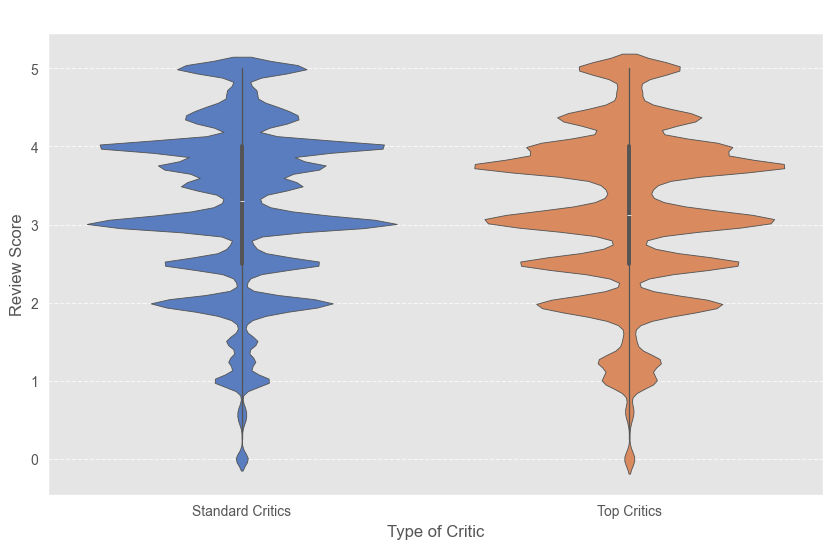

In [142]:
#grafico
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_reviews, x='top_critic', y='review_score',
               hue='top_critic', palette='muted', legend=False)
plt.title('Review Score Distribution: Top Critics vs. Standard Critics')
plt.xlabel('Type of Critic')
plt.ylabel('Review Score')
plt.xticks([0, 1], ['Standard Critics', 'Top Critics'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [143]:
# stats
stats = df_reviews.groupby('top_critic')['review_score'].agg(['mean', 'median', 'std', 'count'])
print(stats)

                mean  median       std   count
top_critic                                    
False       3.252599    3.30  1.055937  569839
True        3.164304    3.12  1.041977  165898


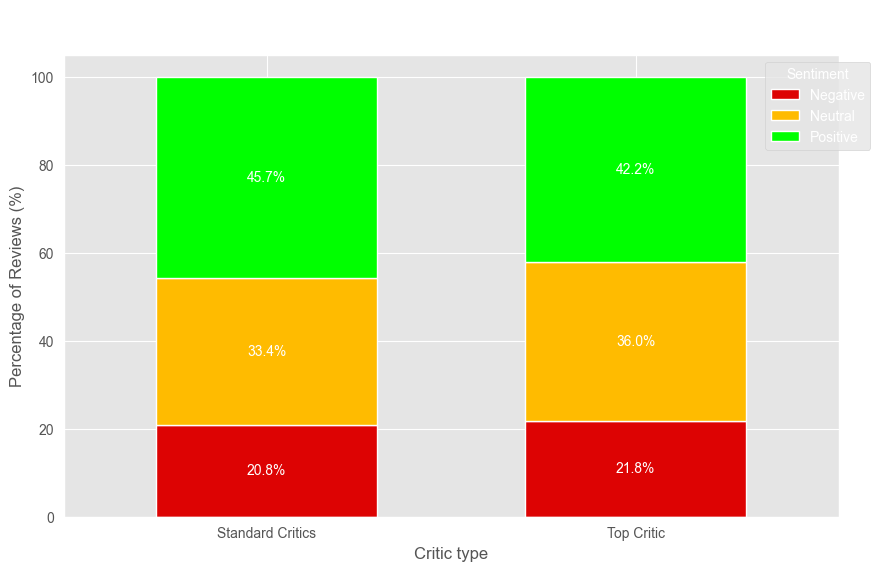

In [144]:
sentiment_labels_with_range = {
    'score < 2.5',
    'score 2.5-3.5',
    'score > 3.5'
}

plt.figure(figsize=(10, 6))

sentiment_colors = ['#DD0303', '#FFBB00', '#00FF00']

ax = sentiment_percents.plot(
    kind='bar',
    stacked=True,
    color=sentiment_colors,
    edgecolor='white',
    linewidth=1,
    width=0.6,
    ax=plt.gca()
)

plt.title('Sentiment Distribution of Reviews\nTop Critic vs Standard')
plt.xlabel('Critic type', fontsize=12)
plt.ylabel('Percentage of Reviews (%)')
plt.xticks([0, 1], ['Standard Critics', 'Top Critic'], rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))

# labels
for p in ax.containers:
    ax.bar_label(p, label_type='center', fmt='%.1f%%', fontsize=10)

plt.show()

## PUNTO 3: Correlation with oscars:

Now that we've established the general strictness of Top Critics, we analyzed whether the Oscars select films that both groups agree upon.\
The data reveals a level of consensus: for Oscar-nominated films that did not win, the average score is identical for both standard and Top Critics (3.90). This suggests that the Academy’s baseline for a nomination meets the approval of the population.\
However, a subtle shift occurs with Oscar Winners: there is a small difference over standard critics (4.08 vs 4.06) which suggests thatTop Critics strongly align with the Academy's top choices

### Data

In [145]:
df_oscars_relevant = df_oscars[['id', 'film', 'year_film', 'category', 'winner']]
df_reviews_relevant = df_reviews[['id', 'review_score', 'top_critic']].rename(columns={'id': 'id'})

# merge between oscars and reviews
df_merged = pd.merge(
    df_reviews_relevant,
    df_oscars_relevant,
    on='id',
    how='inner'
)

df_merged['top_critic_str'] = df_merged['top_critic'].map({True: 'True', False: 'False'})

### Chart

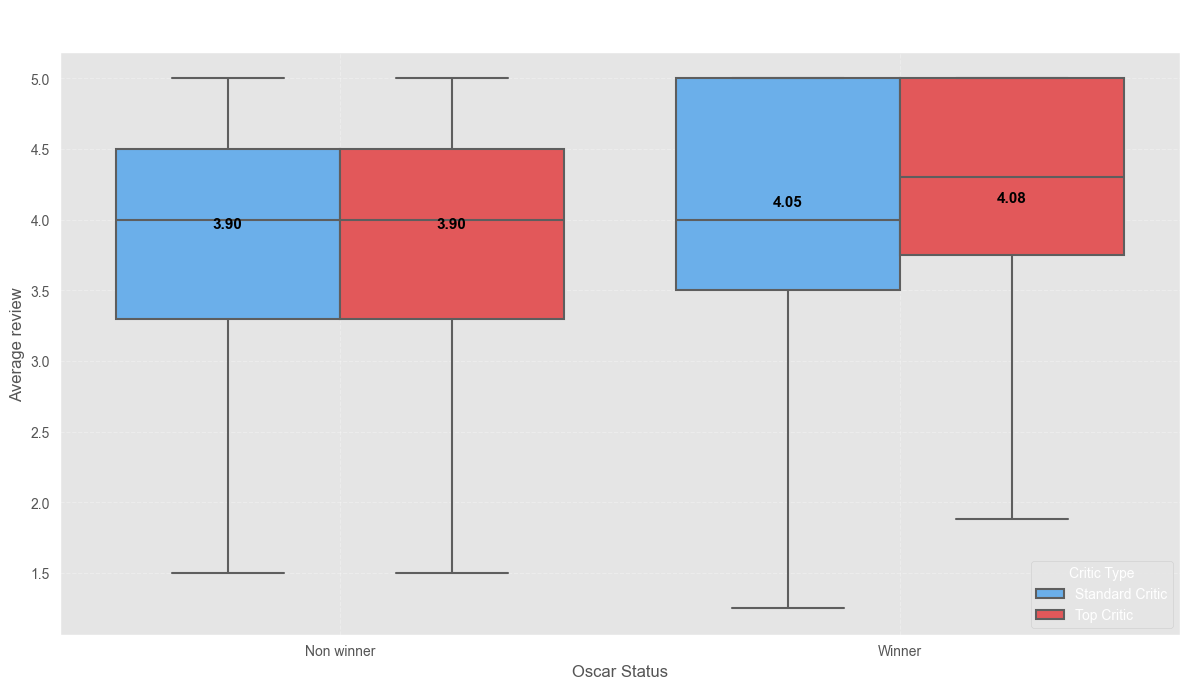

In [146]:
plt.figure(figsize=(12, 7))

box = sns.boxplot(
    data=df_merged,
    x='winner',
    y='review_score',
    hue='top_critic',
    palette={True: '#F94144', False: '#56B0FF'},
    showfliers=False,
    linewidth=1.5
)

plt.title('Critical Consensus on Oscar Nominees vs. Winners)', pad=20)
plt.xlabel('Oscar Status')
plt.ylabel('Average review')
plt.xticks([0, 1], ['Non winner', 'Winner'])
plt.legend(title='Top Critic', labels=['Top Critic', 'Standard'])
plt.grid(True, alpha=0.3, linestyle='--')

handles, labels = box.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Standard Critic', 'Top Critic'], title='Critic Type')

plt.grid(True, alpha=0.3, linestyle='--')

# annotate medians on the plot
medians = df_merged.groupby(['winner', 'top_critic_str'])['review_score'].median().reset_index()
for i, winner_status in enumerate([False, True]):
    for j, is_top in enumerate([False, True]):
        # Filter the data to find the specific median
        subset = df_merged[(df_merged['winner'] == winner_status) & (df_merged['top_critic'] == is_top)]
        mean_val = subset['review_score'].mean()

        x_offset = -0.2 if j == 0 else 0.2
        plt.text(i + x_offset, mean_val + 0.02, f'{mean_val:.2f}',
                 ha='center', va='bottom', fontweight='bold', color='black', fontsize=11)

plt.tight_layout()
plt.show()

In [147]:
# Calculate means, medians, and standard deviations
stats_oscar = df_merged.groupby(['winner', 'top_critic'])['review_score'].agg(
    ['count', 'mean', 'median', 'std']
).reset_index()

print(stats_oscar)

   winner  top_critic   count      mean  median       std
0   False       False  278307  3.897404     4.0  0.920628
1   False        True   56727  3.898518     4.0  0.924932
2    True       False   85747  4.053752     4.0  0.908491
3    True        True   16296  4.083579     4.3  0.902801


In [148]:
# clean up
del df_oscars_relevant, df_reviews_relevant

## PUNTO 4: The Genre Effect on Judgment.

Having confirmed that Top Critics and Standard Critics operate differently and that the Oscar do have a significant influence on the rating we want to know if the genre has also some influence on the ratings.

The analysis confirms that the strictness gap is genre-dependent and reveals a clear preference for cerebral, prestige, and historical genres over commercial, visceral, or mass-market genres.

Top Critics are least strict on genres typically associated with prestige, educational value, and awards potential (Documentary, History). In fact for the documentaries, the strictness gap is only 0.06 points (3.53 vs. 3.47), significantly lower than the overall average difference of 0.09 points.This suggests a critical consensus on the value of informative, fact-based cinema.

On the contrary, Top Critics are harshest on genres associated with pure entertainment, spectacle, or visceral thrills: action shows the largest score gap at 0.17 points (3.05 vs 2.88) and horror movies show the second largest score gap at 0.14 points (2.98 vs 2.84)

The review counts show the market reality: Drama is the dominant genre for both groups (\~273k Standard, \~98k Top Critic reviews), reinforcing its status as the most critically reviewed cinematic form. Comedy is the second most reviewed (\~180k Standard), but its low mean score (3.10 vs 3.00) confirms that high volume does not equate to high critical prais

### Data

In [149]:
# average movie ratings by genre
df_merged_genres = df_reviews.merge(df_genres, on='id', how='inner')
df_merged_genres = df_merged_genres.merge(df_movies[['id', 'rating']], on='id', how='inner').drop_duplicates()

rt_analysis = df_merged_genres.groupby(['genre', 'top_critic'])['review_score'].mean().unstack()
rt_analysis.columns = ['Standard', 'Top Critic']

movie_rating_analysis = df_merged_genres.groupby('genre')['rating'].mean()

df_genre_pivot = rt_analysis.copy()
df_genre_pivot['Movie Dataset'] = movie_rating_analysis

genre_order = df_genre_pivot.mean(axis=1).sort_values(ascending=False).index

df_genre_pivot = df_genre_pivot.loc[genre_order]

genre_counts = df_merged_genres.groupby(['genre', 'top_critic']).size().unstack().fillna(0)
genre_counts = genre_counts.rename(columns={True: 'Top Critic', False: 'Standard'})
genre_counts = genre_counts.loc[genre_order]

### Chart

In [150]:
heatmap_trace = go.Heatmap(
    z=df_genre_pivot.values,
    x=['Standard', 'Top Critic', 'Movie Ratings'],
    y=df_genre_pivot.index,
    colorscale='RdYlGn',
    zmin=df_genre_pivot.min().min()-0.1,
    zmax=df_genre_pivot.max().max()+0.1,
    colorbar=dict(
        title='Score',
        thickness=20,
        tickvals=[
            round(df_genre_pivot.min().min(), 1),
            round(df_genre_pivot.mean().mean(), 1),
            round(df_genre_pivot.max().max(), 1)
        ],
        ticktext=['Low', 'Average', 'High'],
        x=0.23,
        xanchor='left',
        len=0.8,
        y=0.5
    ),
    hovertemplate='Genre: %{y}<br>%{x}<br>Average rating: %{z:.2f}<extra></extra>'
)

fig_combined = make_subplots(
    rows=1, cols=2,
    column_widths=[0.25, 0.75],
     horizontal_spacing=0.15,
    subplot_titles=(
        'Rating Differences by Genre<br><sup>Top Critics vs Standard</sup>',
        'Genre Distribution'
    )
)

fig_combined.update_yaxes(autorange='reversed', row=1, col=1)

# Add heatmap
fig_combined.add_trace(heatmap_trace, row=1, col=1)

for i, row in enumerate(df_genre_pivot.values):
    for j, val in enumerate(row):
        fig_combined.add_annotation(
            text=f"{val:.2f}",
            x=j,
            y=i,
            xref='x1',
            yref='y1',
            showarrow=False,
            font=dict(size=11, color='black')
        )

# Add barchart
colors = ['#56B0FF', '#F94144']
for i, col in enumerate(genre_counts.columns):
    fig_combined.add_trace(
        go.Bar(
            x=genre_counts.index,
            y=genre_counts[col],
            name=col,
            marker_color=colors[i],
            text=genre_counts[col],
            textposition='outside',
            hoverinfo='y+name'
        ),
        row=1, col=2
    )

fig_combined.update_layout(
    height=800,
    font=dict(family="Arial", size=12, color="#FFFFFF"),
    margin=dict(l=80, r=50, b=80, t=100),
    showlegend=True
)

fig_combined.update_xaxes(
    tickmode='array',
    tickvals=[0, 1],
    ticktext=['Standard', 'Top Critic', 'Movie Ratings'],
    row=1, col=1
)

fig_combined.update_yaxes(
    tickangle=0,
    tickfont=dict(size=12),
    automargin=True,
    ticksuffix="   ",
    row=1, col=1
)

fig_combined.show()

In [151]:
# clean up
del df_merged_genres, df_genre_pivot, genre_counts

## PUNTO 5

Having established the genres that attract critical favor (Documentary, History) and those that face the harshest scrutiny (Action, Horror),
 we shift our focus from what critics review to who makes the films.

### Data

In [152]:
# 1. Merge basic data
df_gen = df_movies.merge(df_genres, on="id", how="inner")

# --- Force Year to Integer ---
# We convert the date column to datetime, then extract ONLY the year as an integer.
# This prevents "June 30, 1970" and "July 1, 1970" from being two separate columns.
df_gen['year_int'] = pd.to_datetime(df_gen['date'], errors='coerce').dt.year

# Remove rows without a valid year and cast to integer
df_gen = df_gen.dropna(subset=['year_int'])
df_gen['year_int'] = df_gen['year_int'].astype(int)

# --- FILTER: Keep only data from 1970 to 2025 ---
df_gen = df_gen[(df_gen['year_int'] >= 1970) & (df_gen['year_int'] <= 2025)]

# 2. AGGREGATION: We must sum up everything by Year and Genre first!
# This reduces the dataset from ~50,000 rows to just ~50 years * ~20 genres
genre_year_counts = (
    df_gen.groupby(['year_int', "genre"])
          .size()
          .reset_index(name="count")
)

# 3. Filter top N genres (to keep chart clean)
top_n = 12
top_genres = (
    genre_year_counts.groupby("genre")["count"]
                     .sum()
                     .sort_values(ascending=False)
                     .index
)
genre_year_counts = genre_year_counts[genre_year_counts["genre"].isin(top_genres)]

# 4. Calculate Market Share (%)
# For each year, what % of movies were Action? Drama? etc.
yearly_totals = genre_year_counts.groupby('year_int')["count"].transform("sum")
genre_year_counts["percentage"] = (genre_year_counts["count"] / yearly_totals) * 100

# 5. Create Pivot Tables (The Matrix for the Heatmap)
# Columns will now be strictly integers [1970, 1971, ..., 2025]
heatmap_pct = genre_year_counts.pivot(index="genre", columns='year_int', values="percentage").fillna(0)
heatmap_count = genre_year_counts.pivot(index="genre", columns='year_int', values="count").fillna(0)

# Sort strictly
heatmap_pct = heatmap_pct.sort_index()
heatmap_count = heatmap_count.sort_index()

### Chart

In [153]:
# Use the clean matrices created above
data_color = heatmap_pct
data_real = heatmap_count

# --- HOVER TEXT GENERATION ---
hover_text_matrix = []
for genre in data_color.index:
    row = []
    for year in data_color.columns:
        pct = data_color.loc[genre, year]
        count = data_real.loc[genre, year]

        # Tooltip content
        txt = (f"<b>{genre}</b> ({year})<br>"
               f"Market Share: <b>{pct:.1f}%</b><br>"
               f"Total Movies: {int(count)}")
        row.append(txt)
    hover_text_matrix.append(row)

# Create Heatmap
fig = go.Figure(data=go.Heatmap(
    z=data_color.values,
    x=data_color.columns,
    y=data_color.index,

    hovertext=hover_text_matrix,
    hovertemplate="%{hovertext}<extra></extra>",

    colorscale='Magma',
    xgap=1,
    ygap=1,
    colorbar=dict(title="Market Share (%)")
))

fig.update_layout(
    title={
        'text': "<b>Evolution of Genre Popularity (Market Share %)</b>",
        'font': dict(size=20)
    },
    xaxis_title="Release Year",
    yaxis_title="Genre",
    template="plotly_dark",
    height=600,

    # Axis formatting
    xaxis=dict(
        showgrid=False,
        dtick=5, # Show a label every 5 years
        tickmode='linear',
        range=[1969.5, 2025.5]
    ),
    yaxis=dict(showgrid=False)
)

fig.show()

# A zoom in on Drama, Documentary, History and Comedy

### Data

In [154]:
genres = ['Drama', 'History', 'Documentary', 'Comedy']

# All four genres movies
df_all_genres = df_gen[df_gen['genre'].isin(genres)]
df_all_genres = df_all_genres[df_all_genres['year_int'] <= 2019]

all_movies = df_all_genres.groupby(['genre', 'year_int']).agg(
    num_films=('id', 'nunique')
).reset_index()
all_movies = all_movies[all_movies['num_films'] >= 1]

max_global = all_movies['num_films'].max()
y_max = int(max_global * 1.1)

# Find first review
if 'review_date' in df_reviews.columns:
    first_year = pd.to_datetime(df_reviews['review_date'], errors='coerce').dt.year.min()
    first_year = int(first_year) if not pd.isna(first_year) else 1970
else:
    first_year = 1970

# Reviewed movies
df_reviewed = df_gen[df_gen['genre'].isin(genres)]
df_reviewed = df_reviewed.merge(df_reviews[['id']], on='id', how='inner')
df_reviewed = df_reviewed[
    (df_reviewed['year_int'] >= first_year) &
    (df_reviewed['year_int'] <= 2019)
    ]

all_reviewed_movies = df_reviewed.groupby(['genre', 'year_int']).agg(
    num_films_reviewed=('id', 'nunique')
).reset_index()

# Scores
df_with_scores = df_gen[df_gen['genre'].isin(genres)]
df_with_scores = df_with_scores.merge(
    df_reviews[['id', 'review_score']],
    on='id',
    how='inner'
).dropna(subset=['review_score'])
df_with_scores = df_with_scores[
    (df_with_scores['year_int'] >= first_year) &
    (df_with_scores['year_int'] <= 2019)
    ]

avg_rating_for_genre = df_with_scores.groupby(['genre', 'year_int']).agg(
    num_films_reviewed=('id', 'nunique'),
    avg_rating=('review_score', 'mean')
).reset_index()

In [155]:
fig1 = make_subplots(
    rows=2, cols=2,
    subplot_titles=['<b>Drama</b>', '<b>History</b>', '<b>Documentary</b>', '<b>Comedy</b>'],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

for idx, genre in enumerate(['Drama', 'History', 'Documentary', 'Comedy']):
    row, col = (idx // 2) + 1, (idx % 2) + 1
    genre_values = all_movies[all_movies['genre'] == genre]

    fig1.add_trace(
        go.Scatter(
            x=genre_values['year_int'],
            y=genre_values['num_films'],
            mode='lines+markers',
            line=dict(color='#1f77b4', width=3),
            marker=dict(size=6),
            showlegend=False,
            hovertemplate=f'<b>{genre} %{{x}}</b><br>Movie: %{{y}}<extra></extra>'
        ),
        row=row, col=col
    )

fig1.update_layout(
    title='<b>Movies production by Genre in time (1970-2019)</b>',
    height=800,
    hovermode="x unified",
    template='plotly_white'
)

for row in [1, 2]:
    for col in [1, 2]:
        fig1.update_yaxes(title_text="Movie", row=row, col=col, range=[0, y_max])
        fig1.update_xaxes(title_text="Year", row=row, col=col, range=[1969, 2020], dtick=10)

fig1.show()

In [156]:
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=['<b>Drama</b>', '<b>History</b>', '<b>Documentary</b>', '<b>Comedy</b>'],
    vertical_spacing=0.15,
    horizontal_spacing=0.1,
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]]
)

# Hover
for idx, genre in enumerate(['Drama', 'History', 'Documentary', 'Comedy']):
    row, col = (idx // 2) + 1, (idx % 2) + 1

    all_data = all_movies[all_movies['genre'] == genre]
    reviewed_data = all_reviewed_movies[all_reviewed_movies['genre'] == genre]

    # All movies
    fig2.add_trace(
        go.Scatter(
            x=all_data['year_int'],
            y=all_data['num_films'],
            mode='lines',
            line=dict(color='#1f77b4', width=3),
            showlegend=(idx == 0),
            hovertemplate=f'<b>{genre} %{{x}}</b><br>All movies: %{{y}}<extra></extra>'
        ),
        row=row, col=col, secondary_y=False
    )

    # Reviewed movies
    fig2.add_trace(
        go.Scatter(
            x=reviewed_data['year_int'],
            y=reviewed_data['num_films_reviewed'],
            mode='lines',
            line=dict(color='#ff7f0e', width=3, dash='dash'),
            showlegend=(idx == 0),
            hovertemplate=f'<b>{genre} %{{x}}</b><br>Reviewed movies: %{{y}}<extra></extra>'
        ),
        row=row, col=col, secondary_y=True
    )

fig2.update_layout(
    title=f'<b>All movies vs Reviewed movies production in time ({first_year}-2019)</b>',
    height=800,
    hovermode="x unified",
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)

for row in [1, 2]:
    for col in [1, 2]:
        fig2.update_yaxes(title_text="All movies", secondary_y=False, row=row, col=col, range=[0, y_max])
        fig2.update_yaxes(title_text="Reviewed movies", secondary_y=True, row=row, col=col, range=[0, 250], dtick=50)
        fig2.update_xaxes(title_text="Year", row=row, col=col, range=[first_year-1, 2020])

fig2.show()

In [157]:
fig3 = make_subplots(
    rows=2, cols=2,
    subplot_titles=['<b>Drama</b>', '<b>History</b>', '<b>Documentary</b>', '<b>Comedy</b>'],
    vertical_spacing=0.15,
    horizontal_spacing=0.2,
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]]
)

# Hover
for idx, genre in enumerate(genres):
    row, col = (idx // 2) + 1, (idx % 2) + 1

    # Using avg_rating_for_genre
    genre_data = avg_rating_for_genre[avg_rating_for_genre['genre'] == genre]

    # Reviewed movies hover
    fig3.add_trace(
        go.Scatter(
            x=genre_data['year_int'],
            y=genre_data['num_films_reviewed'],
            mode='lines+markers',
            line=dict(color='#1f77b4', width=3),
            marker=dict(size=6),
            showlegend=(idx == 0),
            hovertemplate=f'<b>{genre} %{{x}}</b><br>Movies: %{{y:,}}<extra></extra>'
        ),
        row=row, col=col, secondary_y=False
    )

    # Reviews scores
    fig3.add_trace(
        go.Scatter(
            x=genre_data['year_int'],
            y=genre_data['avg_rating'],
            mode='lines+markers',
            line=dict(color='#ff7f0e', width=3, dash='dash'),
            marker=dict(size=6),
            showlegend=(idx == 0),
            hovertemplate=f'<b>{genre} %{{x}}</b><br>Reviews scores: %{{y:.2f}}<extra></extra>'
        ),
        row=row, col=col, secondary_y=True
    )

fig3.update_layout(
    title=f'<b>Reviewed movies vs Reviews scores in time({first_year}-2019)</b>',
    height=800,
    hovermode="x unified",
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)

# Axes
for row in [1, 2]:
    for col in [1, 2]:
        # Left: reviewed movies
        fig3.update_yaxes(
            title_text="Reviewed movies",
            secondary_y=False,
            row=row, col=col,
            range=[0, 250]
        )

        # Right: reviews scores
        fig3.update_yaxes(
            title_text="Reviews scores",
            secondary_y=True,
            row=row, col=col,
            range=[1, 5]
        )

        # Asse X
        fig3.update_xaxes(
            title_text="Year",
            row=row, col=col,
            range=[first_year-1, 2020]
        )

fig3.show()

### Data

In [158]:
# Take all movies with a valid time duration
df_filtered = df_gen[df_gen['genre'].isin(genres)].copy()
df_filtered = df_filtered.dropna(subset=['minute'])
df_filtered = df_filtered[(df_filtered['minute'] >= 1) & (df_filtered['minute'] <= 300)]

# Calculate avg review_score for each movie (count scores -> mean -> add to movie)
reviews_with_avg = df_reviews.groupby('id')['review_score'].agg(['mean', 'count']).reset_index()
reviews_with_avg.columns = ['id', 'review_score_mean', 'review_count']

# Merge movies with avg score
df_movie_duration_with_scores = pd.merge(
    df_filtered[['id', 'minute', 'genre']],
    reviews_with_avg[['id', 'review_score_mean']],
    on='id',
    how='inner'
).dropna(subset=['review_score_mean'])

# Rename
df_movie_duration_with_scores = df_movie_duration_with_scores.rename(columns={'review_score_mean': 'review_score'})

# Duration order definition
duration_order = ['<1h', '1-1.5h', '1.5-2h', '2-2.5h', '2.5-3h', '3-3.5h', '3.5-4h', '4-5h']

# Duration categories creation
df_movie_duration_with_scores['duration_category'] = pd.cut(
    df_movie_duration_with_scores['minute'],
    bins=[0, 60, 90, 120, 150, 180, 210, 240, 300],
    labels=duration_order
)

# Convert
df_movie_duration_with_scores['duration_category'] = pd.Categorical(
    df_movie_duration_with_scores['duration_category'],
    categories=duration_order,
    ordered=True
)

# Sort
df_movie_duration_with_scores = df_movie_duration_with_scores.sort_values('duration_category')

In [159]:
fig = px.box(
    df_movie_duration_with_scores,
    x='duration_category',
    y='review_score',
    title='<b>Review Scores for each Duration category</b>',
    labels={'duration_category': 'Duration', 'review_score': 'Review Score'},
    height=600,
    category_orders={'duration_category': duration_order}
)

# Global mean
global_mean = df_movie_duration_with_scores['review_score'].mean()

# Mean red line
fig.add_hline(
    y=global_mean,
    line_dash="dash",
    line_color="red",
    line_width=2,
    opacity=0.7
)

# Avarage label
fig.add_annotation(
    x=1.05,
    y=1.05,
    xref="paper",
    yref="paper",
    text=f"<b>Global average: {global_mean:.2f}</b>",
    showarrow=False,
    font=dict(size=12, color="red")
)

# Remove all hover
fig.update_traces(hoverinfo='skip')

# Layout
fig.update_layout(
    xaxis_title="Duration category",
    yaxis_title="Review Scores",
    template='plotly_white',
    showlegend=False,
    hovermode=False,
    margin=dict(r=120)
)

fig.show()

In [160]:
radar_data = df_movie_duration_with_scores.groupby(['genre', 'duration_category'], observed=False)['review_score'].mean().reset_index()

radar_pivot = radar_data.pivot(
    index='genre',
    columns='duration_category',
    values='review_score'
)

radar_pivot = radar_pivot[duration_order]

colors = px.colors.qualitative.Plotly
genre_order = ['Drama', 'History', 'Documentary', 'Comedy']
genre_colors = {genre: colors[i % len(colors)] for i, genre in enumerate(genre_order)}

fig = go.Figure()

for genre in genre_order:
    if genre in radar_pivot.index:
        values = radar_pivot.loc[genre].values.tolist()
        values_closed = values + [values[0]]
        categories_closed = duration_order + [duration_order[0]]

        hex_color = genre_colors[genre].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
        rgba_color = f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, 0.3)'

        fig.add_trace(go.Scatterpolar(
            r=values_closed,
            theta=categories_closed,
            name=genre,
            fill='toself',
            fillcolor=rgba_color,
            line=dict(color=genre_colors[genre], width=2)
        ))

fig.update_layout(
    title='<b>Review Scores for Duration categories and Genres</b>',
    polar=dict(
        radialaxis=dict(
            range=[2.5, 4.5],
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            rotation=90,
            direction='clockwise'
        )
    ),
    showlegend=True,
    legend=dict(
        title='<b>Genre</b>',
        y=0.99,
        x=1.1
    ),
    height=700,
    width=800
)

fig.show()

## PUNTO 6

The following heatmap, based on Oscar nominations, reveals the cinematic identities of the world's major filmmaking nations, highlighting their genre specialization.

As predictable, we can see that the USA dominates absolutely in volume across all major genres, particularly Drama and Comedy. Another country that dominates nearly every genre is  the UK, especially Drama and History.

Looking at nominations by genre  we can see that Drama is the genre that dominates globally, but the heatmap also reveals some instances of genre specialization:
- Japan has a high count of nominations in Animation (20) compared to other genre nominations
- New Zeland's high volume of nominations in Fantasy (39) and Adventure (38) is an obvious marker of the success of the franchises "The Lord of the Rings" and "The Hobbit"
- Italy's highest non-Drama concentration is Comedy (52) followed by Romance (38)
- Both France and Germay show a strong leaning toward the intellectual: France's second higest genres is Docmumentary (50), while in Germany is Thriller (47) followed by Documentary (44)
- India, while heavily focused on dramea the high count in Romance (37) highlights the unique influence of Bollywood.
- In Hong Kong Action (24) is a primary genre, alongside Drama (61) and Romance (39), confirming its historical reputation as a powerhouse for martial arts and police action cinema



### Data

In [161]:
# --- 1. DATA MERGING ---
# Filter Oscars entries with a valid movie ID and merge with countries
oscars_with_country = pd.merge(df_oscars, df_countries, on='id', how='inner')

# Merge movies and genres (keeping movie name for reference if needed)
movies_genres = pd.merge(df_movies[['id', 'name']], df_genres, on='id', how='left')

# Merge everything into one dataframe
oscars_genres = pd.merge(
    oscars_with_country,
    movies_genres,
    left_on='id',
    right_on='id',
    how='left'
)

# Keep only relevant columns
oscars_genres = oscars_genres[['id', 'country', 'genre']]

# --- 2. PIVOT TABLE CREATION ---
# Rows: Country, Columns: Genre, Values: Count of IDs
heatmap_data = oscars_genres.pivot_table(
    index='country',
    columns='genre',
    values='id',
    aggfunc='count',
    fill_value=0
)

# --- 3. FILTERING ---
# Calculate total nominations per country
country_totals = heatmap_data.sum(axis=1)

# Filter: Keep top 15 countries in number of nominations
top_countries = (
    oscars_with_country['country']
    .value_counts()
    .head(15)
    .index
)

filtered_oscars = oscars_with_country[
    oscars_with_country['country'].isin(top_countries)
]
heatmap_filtered = heatmap_data.loc[top_countries]

# Sort countries by total nominations (descending) for better visual flow
heatmap_filtered = heatmap_filtered.loc[heatmap_filtered.sum(axis=1).sort_values(ascending=False).index]

# --- 4. LOGARITHMIC TRANSFORMATION ---
# We use log for the COLOR scale so small countries don't disappear,
# but we will use 'heatmap_filtered' for the HOVER text so users see real numbers.
log_data = np.log1p(heatmap_filtered)

### Chart

In [162]:
# Data preparation
data_color = log_data.T       # Data for COLORS (Log scale)
data_real = heatmap_filtered.T # Data for HOVER (Real numbers)

# --- FAIL-SAFE HOVER TEXT GENERATION ---
# We build the hover text manually in Python.
# This ensures exactly the right text appears for every cell, avoiding Plotly mapping errors.
hover_text_matrix = []
for genre in data_real.index:
    row = []
    for country in data_real.columns:
        val = data_real.loc[genre, country]
        # Create the HTML string for this specific cell
        txt = f"<b>{genre}</b><br>{country}<br>Nominations: {val}"
        row.append(txt)
    hover_text_matrix.append(row)
# ---------------------------------------

#  Bar labels
max_val = heatmap_filtered.values.max()
log_max = np.log1p(max_val)
tick_vals = [0, np.log1p(10), np.log1p(100), np.log1p(1000), log_max]
tick_text = ["0", "10", "100", "1000", f"{int(max_val)}"]

# Create the Heatmap
fig = go.Figure(data=go.Heatmap(
    z=data_color.values,       # Colors based on log scale
    x=data_color.columns,      # X-axis: Countries
    y=data_color.index,        # Y-axis: Genres

    # Pass the pre-formatted text matrix we created above
    hovertext=hover_text_matrix,

    # Simply tell Plotly to use that text
    hovertemplate="%{hovertext}<extra></extra>",

    colorscale='Viridis',
    xgap=1,
    ygap=1,

    colorbar=dict(
        title="Nominations",
        tickvals=tick_vals,    
        ticktext=tick_text     
    )
    
))

# Layout Settings
fig.update_layout(
    title="Nominations by Country and Genre",
    xaxis_title="Country",
    yaxis_title="Genre",
    template="plotly_dark",
    height=800,
    xaxis=dict(tickangle=-45)
)


fig.show()

Across almast all major filmmacking countries the top-nominated themes revolve around human relationships (Moving relationship stories) and societal context (Humanity and the world around us).
Germany, and to a significant extent the UK, clearly specialize in narratives centered on War, History, and Politics.
or both France and Hong Kong, specific romance themes (Captivating relationships and charming romance) are highly ranked in their Oscar-nominated output

In [163]:
# cleanup
del oscars_with_country, oscars_genres, heatmap_data, country_totals, top_countries, heatmap_filtered, log_data

## PUNTO 7

This visualization shows the film genres that are most widely released outside their production countries — used here as a proxy for dubbing or localization.
Each bar represents the average number of foreign countries where films of that genre were released.
Although this doesn’t directly measure dubbing, it provides a reasonable indication of which genres are most frequently distributed and adapted internationally.
For example, genres with higher averages (e.g., Action or Animation) tend to have broader global appeal and are therefore more likely to be dubbed into multiple languages.

### Data

In [164]:
import pandas as pd

# ==== Data Preparation: Stratified Language Diversity ====

# 1. Count unique languages per movie
# We count how many unique languages are associated with each movie ID
movie_lang_counts = (
    df_languages.groupby("id")["language"]
    .nunique()
    .reset_index(name="unique_lang_count")
)

# 2. Merge language data with genres
df_lang_genre = movie_lang_counts.merge(df_genres, on="id", how="inner")

# 3. Aggregate by genre: calculate Average Diversity AND total Movie Count
# 'movie_count' is the frequency of movies in that genre
genre_stats = (
    df_lang_genre.groupby("genre")["unique_lang_count"]
    .agg(avg_lang_diversity='mean', movie_count='count')
    .reset_index()
)

# 4. Calculate the Median of the movie counts
# We calculate the median frequency to split the 19 genres into two balanced groups
# This median refers to: "What is the middle-point of popularity among genres?"
threshold_median = genre_stats["movie_count"].median()

# 5. Split into two groups based on the median threshold
df_major = (
    genre_stats[genre_stats["movie_count"] >= threshold_median]
    .sort_values(by="avg_lang_diversity", ascending=True)
)

df_niche = (
    genre_stats[genre_stats["movie_count"] < threshold_median]
    .sort_values(by="avg_lang_diversity", ascending=True)
)

### Chart

In [165]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(f"Major Genres", f"Niche Genres"),
    horizontal_spacing=0.2
)

# Template logic:
# %{y} -> Genre name
# %{x:.2f} -> Average languages (2 decimal places)
# %{customdata[0]} -> Movie count
# <extra></extra> -> Removes the secondary "trace name" box
custom_hover = (
    "<b>%{y}</b><br>" +
    "Avg. Languages: <b>%{x:.2f}</b><br>" +
    "Sample Size: <i>%{customdata[0]} movies</i>" +
    "<extra></extra>"
)

# Add Major Genres
fig.add_trace(
    go.Bar(
        x=df_major["avg_lang_diversity"],
        y=df_major["genre"],
        orientation='h',
        marker=dict(color=df_major["avg_lang_diversity"], colorscale="Viridis"),
        text=df_major["avg_lang_diversity"].round(2),
        textposition="outside",
        customdata=df_major[["movie_count"]], # Passing movie count to the hover
        hovertemplate=custom_hover,
        cliponaxis=False
    ),
    row=1, col=1
)

# Add Niche Genres
fig.add_trace(
    go.Bar(
        x=df_niche["avg_lang_diversity"],
        y=df_niche["genre"],
        orientation='h',
        marker=dict(color=df_niche["avg_lang_diversity"], colorscale="Plasma"),
        text=df_niche["avg_lang_diversity"].round(2),
        textposition="outside",
        customdata=df_niche[["movie_count"]], # Passing movie count to the hover
        hovertemplate=custom_hover,
        cliponaxis=False
    ),
    row=1, col=2
)

# Layout improvements
max_val = max(df_major["avg_lang_diversity"].max(), df_niche["avg_lang_diversity"].max())
x_limit = max_val * 1.2 # Extra buffer for the 'textposition="outside"'

fig.update_layout(
    title_text="<b>Linguistic Diversity Analysis by Genre</b>",
    template="plotly_dark",
    showlegend=False,
    height=700,
    margin=dict(t=100, l=160, r=100, b=50),
    # Hover style: make it look like a clean tooltip
    hoverlabel=dict(
        bgcolor="#222",
        font_size=13,
        font_family="Arial"
    )
)

fig.update_xaxes(range=[0, x_limit], row=1, col=1)
fig.update_xaxes(range=[0, x_limit], row=1, col=2)

fig.show()

## PUNTO 8

This visualization shows which film genres have won the most Academy Awards.
Each bar represents the total number of Oscar wins for films belonging to that genre.
Although some films span multiple genres, this view helps highlight the types of movies most frequently recognized by the Academy — for example, Drama and Biography often dominate due to their strong storytelling and critical appeal.

### Data

In [166]:
import pandas as pd

# ==== Data Preparation: Oscar Wins + Top Movies per Genre ====

# 1. Filter wins
if "winner" in df_oscars.columns:
    df_oscars_wins = df_oscars[df_oscars["winner"] == 1].copy()
else:
    df_oscars_wins = df_oscars.copy()

# 2. Prepare Movie Names explicitly
# We take only ID and Name from movies and rename 'name' to 'movie_title' to avoid confusion with countries
movies_clean = df_movies[["id", "name"]].rename(columns={"name": "movie_title"})

# 3. Merge: Oscars -> Genres -> Movie Titles
oscars_full = df_oscars_wins.merge(df_genres, on="id", how="left")
oscars_full = oscars_full.merge(movies_clean, on="id", how="left")

# 4. Aggregation 1: Count wins per genre
genre_oscar_counts = (
    oscars_full.groupby("genre")
               .size()
               .reset_index(name="oscar_wins")
               .sort_values(by="oscar_wins", ascending=False)
)

# 5. Aggregation 2: Find TOP 3 movies for each genre using the CLEAN title
def get_top_movies(series):
    # Filter out values that look like countries if needed, or just take the top frequent titles
    # taking the top 3 most frequent titles associated with wins in this genre
    top_list = series.value_counts().head(3).index.tolist()
    # Format as a bullet list
    return "<br>   • " + "<br>   • ".join(str(x) for x in top_list)

top_movies_per_genre = (
    oscars_full.groupby("genre")["movie_title"] # We use the explicit movie_title column
               .apply(get_top_movies)
               .reset_index(name="top_movies_str")
)

# 6. Merge everything
final_df = genre_oscar_counts.merge(top_movies_per_genre, on="genre", how="left")

# 7. Calculate Percentage
total_wins = final_df["oscar_wins"].sum()
final_df["win_share"] = (final_df["oscar_wins"] / total_wins) * 100

# Take all genres
top_genre_oscar = final_df.copy()

# 8. Add Podium Colors, we'll take colors from the next chart
top_genre_oscar = final_df.copy()

top_genre_oscar["color_hex"] = (podium_colors + rest_color)[:num_genres]

NameError: name 'podium_colors' is not defined

### Chart

In [167]:
import plotly.express as px

fig = px.bar(
    top_genre_oscar,
    x="genre",
    y="oscar_wins",
    color="oscar_wins",
    color_continuous_scale=["#404040", "#D4AF37"], # Da grigio a oro
    text_auto=True,
    custom_data=["genre", "oscar_wins", "win_share", "top_movies_str"]
)

fig.update_traces(
    textfont_size=16,
    textfont_weight="bold",
    textposition="outside",
    cliponaxis=False,
    marker_line_color='rgba(255, 255, 255, 0.3)',
    marker_line_width=1,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "Wins: %{customdata[1]}<br>"
        "Share: %{customdata[2]:.1f}%<br>"
        "<br><b>Most Awarded Movies:</b>"
        "%{customdata[3]}"
        "<extra></extra>"
    )
)

fig.update_layout(
    title={
        'text': "<b>The Oscar Podium: Top Genres by Wins</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': dict(size=24, color='#D4AF37')
    },
    xaxis_title="",
    yaxis_title="Number of Statuettes",
    template="plotly_dark",

    xaxis=dict(
    showgrid=False,
    tickfont=dict(size=12, color='white'),
    tickangle=45  # Ruota i nomi dei generi di 45 gradi
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='rgba(255, 255, 255, 0.1)',
        showticklabels=True
    ),
    margin=dict(t=100)
)

fig.show()

## PUNTO 9

This visualization compares the average audience ratings of different film genres across two historical periods: Normal (before 1990) and Recent (after 1990).
The chart highlights how critical reception varies over time, showing which genres tend to achieve higher or lower ratings.
The y-axis is standardized on a 0–5 scale to make genre comparisons easier.
For example, genres like Drama and Documentary often maintain higher average ratings, while Horror or Action may receive more polarized reviews.

### Data

In [168]:
import pandas as pd

# ==== Data Preparation: Ratings & Historical Consistency ====

# 1. Determine the earliest review date to set a historical baseline
if 'review_date' in df_reviews.columns:
    # Ensure review_date is datetime and extract the minimum year
    first_review_year = pd.to_datetime(df_reviews['review_date'], errors='coerce').dt.year.min()
    first_review_year = int(first_review_year) if not pd.isna(first_review_year) else 1970
else:
    first_review_year = 1970

# 2. Calculate the average score for each movie from the review dataset
# Using 'review_score' (the cleaned numerical column)
movie_stats = (
    df_reviews.groupby("id")["review_score"]
              .mean()
              .reset_index(name="calculated_avg_rating")
)

# 3. Merge metadata: Reviews -> Movies -> Genres
df_gen = df_movies.merge(movie_stats, on="id", how="inner")
df_gen = df_gen.merge(df_genres, on="id", how="left")

# 4. Filter movies released from the first review year onwards
# This ensures we don't compare modern ratings of old movies with contemporary movies
df_gen["movie_year"] = pd.to_datetime(df_gen["date"], errors="coerce").dt.year
df_gen = df_gen[df_gen["movie_year"] >= first_review_year]

# 5. Define Time Periods (Cutoff 1990)
cutoff_year = 1990
df_gen["period"] = df_gen["movie_year"].apply(
    lambda y: "Normal" if y < cutoff_year else "Recent"
)

# 6. Aggregate by Period and Genre
genre_rating = (
    df_gen.groupby(["period", "genre"])["calculated_avg_rating"]
          .mean()
          .reset_index(name="avg_rating")
)

# 7. Final sort for better visualization
best_worst = genre_rating.sort_values(by=["period", "avg_rating"], ascending=[True, False])

### Chart

In [169]:
import plotly.express as px

# Create the bar chart
fig = px.bar(
    best_worst,
    x="genre",
    y="avg_rating",
    color="avg_rating",  # Color mapping based on score
    facet_col="period",  # Separates "Normal" and "Recent" into two sub-plots
    color_continuous_scale="RdYlGn", # Red-Yellow-Green scale
    custom_data=["genre", "period", "avg_rating"],
    text_auto=".2f" # Show the score on top of the bars
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>Genre:</b> %{customdata[0]}<br>"
        "<b>Period:</b> %{customdata[1]}<br>"
        "<b>Avg Rating:</b> %{customdata[2]:.2f}<extra></extra>"
    )
)

fig.update_layout(
    title=f"<b>Average Ratings by Genre (From {first_review_year} to Present)</b>",
    xaxis_title="",
    yaxis_title="Average Rating",
    template="plotly_dark",
    coloraxis_colorbar=dict(title="Score"), # Label for the color bar
    margin=dict(t=100)
)

# Set the Y axis range consistently across all subplots
fig.update_yaxes(range=[0, 5.5], showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)')

# Rotate labels for readability
fig.update_xaxes(tickangle=45)

fig.show()

###    ESPORTAZIONE DATASET

In [170]:
# create output folder
#os.makedirs('output', exist_ok=True)

# Esporta il dataframe in formato csv
#df_languages.to_csv('output/languages_clean.csv', index = False)
#df_movies.to_csv('output/movies_clean.csv', index = False)
#df_posters.to_csv('output/posters_clean.csv', index = False)
#df_releases.to_csv('output/releases_clean.csv', index = False)
#df_studios.to_csv('output/studios_clean.csv', index = False)
#df_themes.to_csv('output/theme_clean.csv', index = False)
#df_reviews.to_csv('output/review_clean.csv', index = False)
#df_oscars.to_csv('output/oscars_clean.csv', index = False)
#df_actors.to_csv('output/actors_clean.csv', index = False)
#.to_csv('output/countries_clean.csv', index = False)
#df_crew.to_csv('output/crew_clean.csv', index = False)
#df_genres.to_csv('output/genres_clean.csv', index = False)